In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = {
    "size_sqft": [1000, 1500, 1200, 2000, 1800],
    "num_bedrooms": [3, 4, 3, 5, 4],
    "num_bathrooms": [2, 3, 2, 4, 3],
    "location": ["Dhaka", "Chittagong", "Dhaka", "Sylhet", "Chittagong"],
    "year_built": [2000, 2010, 2005, 2015, 2012],
    "has_garage": [1, 1, 0, 1, 0],
    "price": [100000, 150000, 120000, 200000, 180000]
}

df = pd.DataFrame(data)

In [3]:
df["house_age"] = 2026 - df["year_built"]
df["location"] = df["location"].map({"Dhaka":1, "Chittagong":2, "Sylhet":3})

In [4]:
X = df[["size_sqft","num_bedrooms","num_bathrooms","location","has_garage","house_age"]]
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [6]:
y_pred = model.predict(X_test)

In [7]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 6800.0
MSE: 46240000.0
R2 Score: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


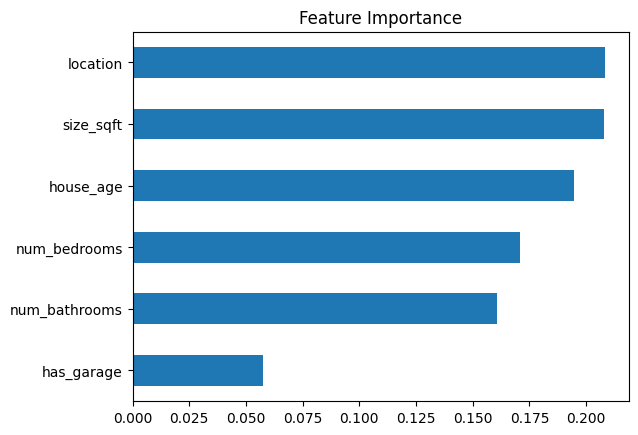

In [8]:
import matplotlib.pyplot as plt
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.sort_values().plot(kind='barh', title="Feature Importance")
plt.show()